In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [2]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
N_chamber = 10
x_scale = 10000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [ ]:
# Set limits of characteristic size of chamber
R_ref = 100
# Uniformly randomly distribution volume
V_ref = (4/3)*np.pi*R_ref**3

# List generation of chamber characteristics
x_nodes = np.array([-5000,  4000,  0    ])
y_nodes = np.array([-0,     0,     0    ])
z_nodes = np.array([20000,  22000, 25000])
V_nodes = np.array([4.0,    0.25,  1 ]) * V_ref

# Symmetric distance matrix
d = np.sqrt((x_nodes - x_nodes[:,np.newaxis]) ** 2
     + (y_nodes - y_nodes[:,np.newaxis]) ** 2
     + (z_nodes - z_nodes[:,np.newaxis]) ** 2)

list_nodes = [MagmaChamber(
                    x=x,
                    y=y,
                    z=z,
                    p_setting=0.0,
                    p0=0,
                    T_setting=1200,
                    V_setting=V)
              for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]

In [ ]:
# Set up for timestepping later
global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                   r_hydr=r_hydr, mu0=mu0, 
                                   rho0=2500, K_f=K_f, Nr=50,
                                   dpdx_crit=1e3,
                                   dpdx_threshold_scale=0.0,#1e2,
                                   R_outer_ratio=20, max_edge_dist=9e99)


# Source term due to eruption at node -1
f_erupt = global_sys.create_eruption_source(p_erupt=5e6, mu_erupt=1e5, r_conduit=2500)

# Instead of source term due to mass injection at node 0...
# f_inj = global_sys.create_single_mass_injection_source(3.0)

# Define multiple injections
# mdot_inj1 = 0.3 # SET 1
# mdot_inj2 = 0.6 # SET 1
mdot_inj1 = 4.5
mdot_inj2 = 6

def f_inj_multiple(t, q):
  f_inj = np.zeros((global_sys.num_dof))
  f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj1
  f_inj[global_sys.data_slice_global(1, "mass")] = mdot_inj2
  return f_inj

In [195]:
t_vec = np.linspace(0, 50e7, 10000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj_multiple, f_erupt)
m, p, u = global_sys.compute_m_p_u(q_out)

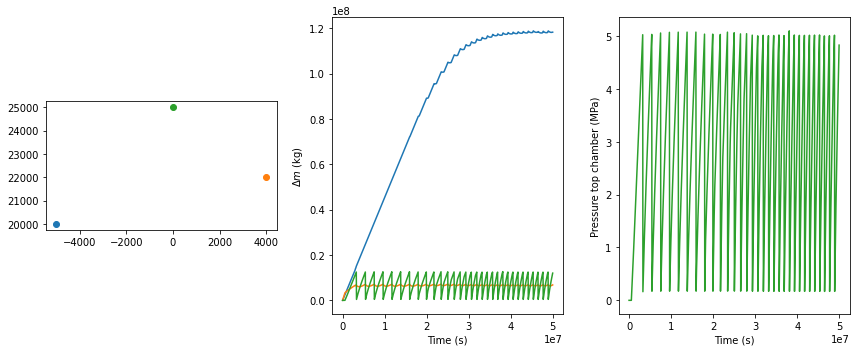

In [202]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
N_chambers = len(x_nodes)
for i in range(N_chambers):
  plt.scatter(x_nodes[i], z_nodes[i], c=color_cycle[i])
plt.gca().set_aspect('equal')

plt.subplot(1,3,2)
plot_idx = 1000
plt.plot(t_vec[:plot_idx], m[:,0][:plot_idx] - m[:,0][0])
plt.plot(t_vec[:plot_idx], m[:,1][:plot_idx] - m[:,1][0])
plt.plot(t_vec[:plot_idx], m[:,2][:plot_idx] - m[:,2][0])
plt.xlabel("Time (s)")
plt.ylabel("$\Delta m$ (kg)")

plt.subplot(1,3,3)
plt.plot(t_vec[:plot_idx], p[:,2][:plot_idx] / 1e6, color=color_cycle[2])
plt.xlabel("Time (s)")
plt.ylabel("Pressure top chamber (MPa)")
plt.tight_layout()

Text(0, 0.5, 'Time of occurence (s)')

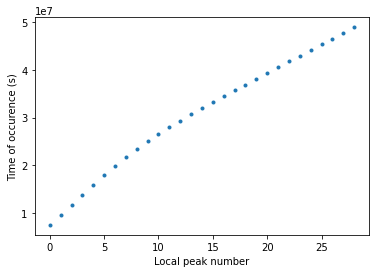

In [203]:
''' Peak picking '''
# Take data series
series = p[:,2][:plot_idx] / 1e6

# Compute boolean values corresponding to sign changes
is_peak = (np.diff(series[1:]) > 0).astype(float) * (np.diff(series[:-1]) < 0).astype(float)
# First time data is over 99% of the max
first_index = np.argmax(series > 0.99 * series.max())
# Compute indices where peak is detected in data series
peak_indices = (first_index + 1 + np.where(is_peak[first_index:])).squeeze()
plt.plot(t_vec[peak_indices], '.')
plt.xlabel("Local peak number")
plt.ylabel("Time of occurence (s)")